#  Air Quality Index (AQI) Prediction System

## Semester Project - Deliverable 2

### Team Members
- **Muhammad Abdullah Ismail**
- **Muhammad Sufian Zahid**
- **Mahira Ali**
- **Kinza Chaudhry**

### Course
Machine Learning for Data Science

### Date
May 2026

---

##  Project Overview
This project develops a machine learning system to predict Air Quality Index (AQI) categories based on pollutant measurements. The system takes 11 real-time pollutant readings and classifies air quality into six categories: Good, Satisfactory, Moderate, Poor, Very Poor, and Severe.

### Dataset
- **Source**: Central Pollution Control Board (CPCB), India
- **Time Period**: 2015 - 2020
- **Records**: 29,531 rows
- **Cities**: 26 Indian cities

### Models Implemented
1. Logistic Regression (Baseline)
2. Random Forest (Ensemble)
3. Support Vector Machine (SVM)
4. MLP Neural Network (Deep Learning)

---

In [4]:
# Install Required Libraries
!pip install imbalanced-learn xgboost lightgbm catboost -q
print("✅ Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.9 MB/s eta 0:00:00
✅ Libraries installed successfully!


In [5]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# Load Dataset
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Saving city_day.csv to city_day.csv
Dataset loaded: 29,531 rows × 16 columns

First 5 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


##  Data Preprocessing

### Steps Performed:
1. **Drop Redundant Columns** - Remove 'Xylene' due to high missing values (61%)
2. **Handle Missing Values** - Median imputation for all numeric columns
3. **Clean Target Variable** - Remove rows with missing AQI_Bucket values
4. **Encode Target** - Convert categorical AQI_Bucket to numerical labels

### Rationale:
- Median imputation preserves the central tendency without being skewed by outliers
- Dropping rows with missing target ensures valid training labels
- Label encoding enables multi-class classification

In [7]:


df.drop(columns=['Xylene'], inplace=True)


numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)


before = len(df)
df.dropna(subset=['AQI_Bucket'], inplace=True)
print(f"Dropped {before - len(df)} rows. Shape: {df.shape}")

Dropped 4681 rows. Shape: (24850, 15)


##  Feature Engineering

### New Features Created (10 total):

#### Temporal Features
- **Month_Sin / Month_Cos** - Cyclic encoding of months (captures seasonal patterns)
- **Is_Weekend** - Weekend/weekday indicator
- **Year_Normalized** - Normalized year for temporal trends

#### Pollution Ratios
- **PM_Ratio** = PM2.5 / (PM10 + 0.01) - Captures fine vs coarse particle ratio
- **NOx_NO2_Ratio** = NOx / (NO2 + 0.01) - Indicates NOx composition

#### Interaction Features
- **PM_CO_Interaction** = PM2.5 × CO - Combined effect of particles and carbon monoxide
- **NOx_SO2_Interaction** = NOx × SO2 - Combined effect of nitrogen and sulfur oxides

#### Composite Indices
- **Composite_PM** = 0.6×PM2.5 + 0.4×PM10 - Weighted particulate matter index
- **Composite_Nox** = 0.3×NO + 0.4×NO2 + 0.3×NOx - Weighted nitrogen oxide index

### Why These Features?
Engineered features often capture non-linear relationships and interactions that raw pollutants miss, leading to better model performance.

In [8]:


df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)
df['PM_Ratio'] = df['PM2.5'] / (df['PM10'] + 0.01)
df['NOx_NO2_Ratio'] = df['NOx'] / (df['NO2'] + 0.01)
df['PM_CO_Interaction'] = df['PM2.5'] * df['CO']
df['NOx_SO2_Interaction'] = df['NOx'] * df['SO2']
df['Composite_PM'] = df['PM2.5'] * 0.6 + df['PM10'] * 0.4
df['Composite_Nox'] = df['NO'] * 0.3 + df['NO2'] * 0.4 + df['NOx'] * 0.3
df['Year_Normalized'] = (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min())

print("Feature engineering complete! Created 10 new features.")

Feature engineering complete! Created 10 new features.


##  Feature and Target Preparation

### Feature Columns (21 total)
The final feature set includes:
- **Primary Pollutants**: PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene
- **Engineered Features**: PM_Ratio, NOx_NO2_Ratio, PM_CO_Interaction, NOx_SO2_Interaction
- **Temporal Features**: Month_Sin, Month_Cos, Is_Weekend, Year_Normalized
- **Composite Indices**: Composite_PM, Composite_Nox

### Target Variable
- **AQI_Bucket** - Encoded to numerical values using LabelEncoder
  - Good → 0
  - Satisfactory → 1
  - Moderate → 2
  - Poor → 3
  - Very Poor → 4
  - Severe → 5

### Scaling
StandardScaler is applied to normalize all features to zero mean and unit variance.

In [9]:

feature_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene',
                'PM_Ratio', 'NOx_NO2_Ratio', 'PM_CO_Interaction', 'NOx_SO2_Interaction',
                'Month_Sin', 'Month_Cos', 'Is_Weekend', 'Composite_PM', 'Composite_Nox', 'Year_Normalized']

le = LabelEncoder()
df['AQI_Encoded'] = le.fit_transform(df['AQI_Bucket'])

X = df[feature_cols].copy()
y = df['AQI_Encoded'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print(f"Features: {len(feature_cols)}")
print(f"Target classes: {list(le.classes_)}")
print(f"X shape: {X_scaled.shape}, y shape: {y.shape}")

Features: 21
Target classes: ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']
X shape: (24850, 21), y shape: (24850,)


##  Exploratory Data Analysis (EDA)

### Visualizations Generated:

1. **Class Distribution** - Shows frequency of each AQI category (imbalance visible)
2. **Correlation Heatmap** - Reveals relationships between key pollutants
3. **PM2.5 Distribution by Category** - How PM2.5 levels vary across AQI categories
4. **Monthly AQI Trend** - Seasonal patterns in air quality
5. **Pollutant Impact on AQI** - Which pollutants most influence AQI
6. **Top Cities AQI Breakdown** - Geographic distribution of air quality

### Key Insights from EDA:
- PM2.5 and PM10 show strong positive correlation with AQI
- Winter months (Nov-Feb) show higher pollution levels
- Metropolitan cities tend to have more "Poor" and "Very Poor" days
- Class imbalance exists - "Moderate" and "Satisfactory" are overrepresented

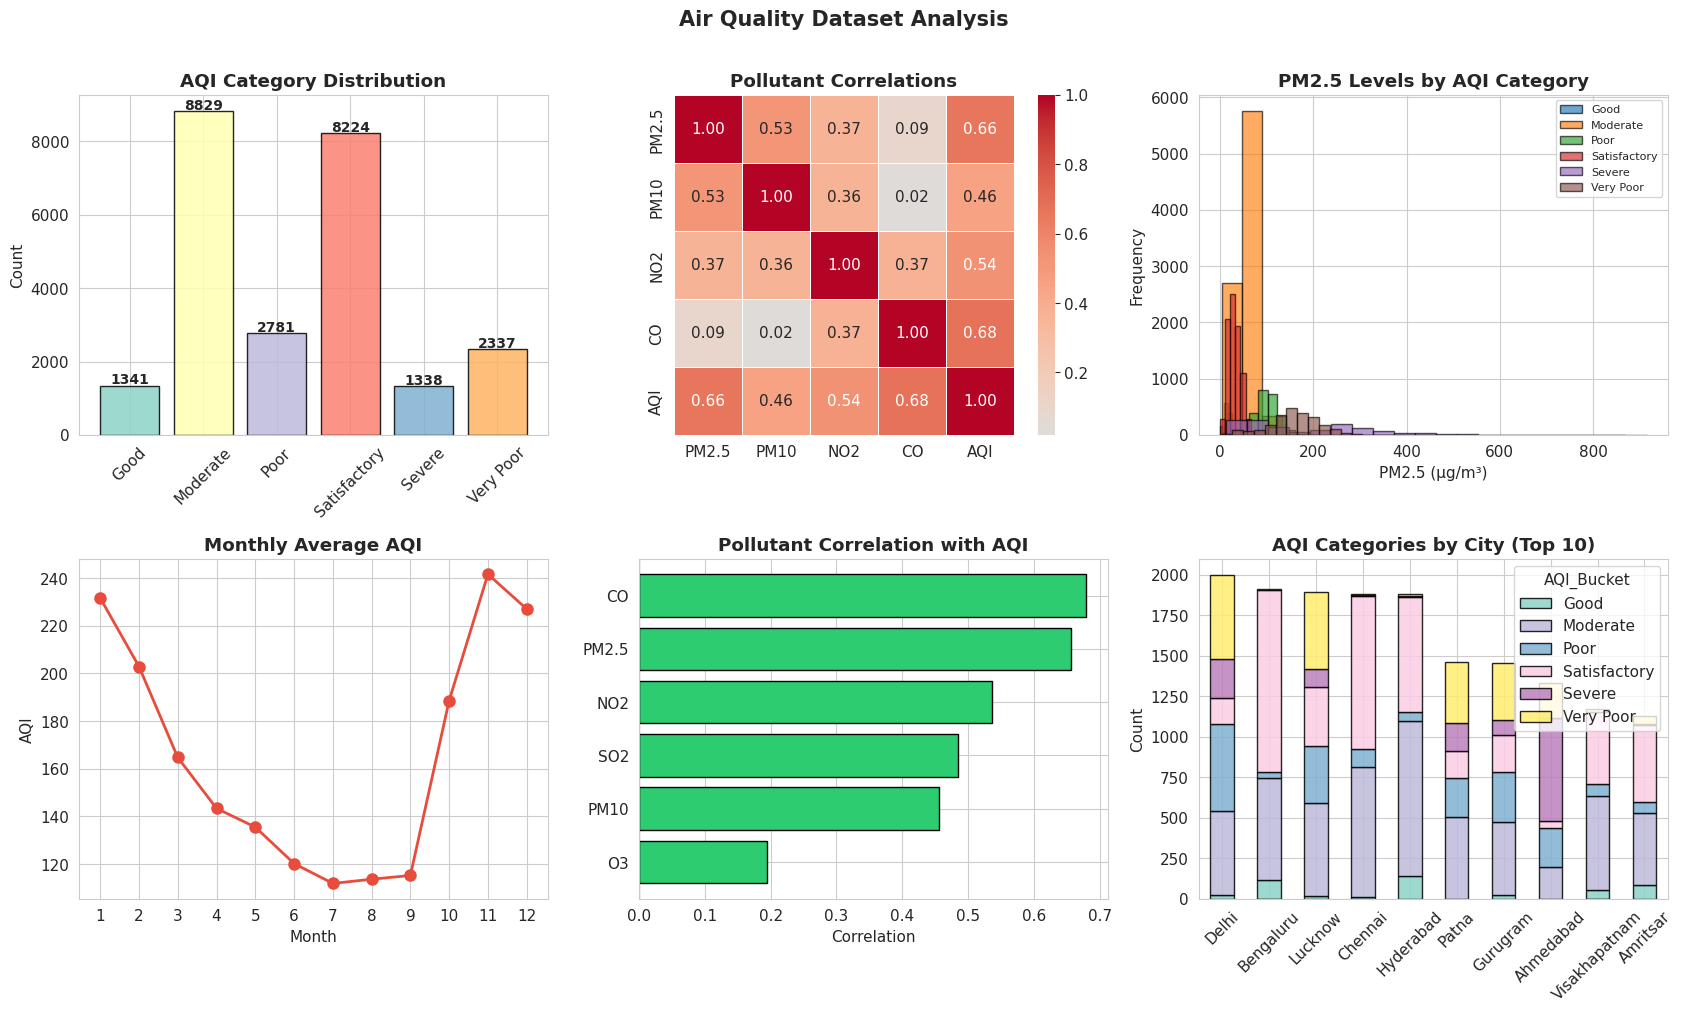

✅ Saved: eda_visualizations.png


In [10]:


fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Air Quality Dataset Analysis', fontsize=15, fontweight='bold', y=1.01)


class_counts = y.value_counts().sort_index()
bars = axes[0, 0].bar(
    [le.classes_[k] for k in class_counts.index],
    class_counts.values,
    color=plt.cm.Set3(range(len(class_counts))),
    edgecolor='black', alpha=0.85
)
for bar, val in zip(bars, class_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(val),
                    ha='center', fontweight='bold', fontsize=10)
axes[0, 0].set_title('AQI Category Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)


key_features = ['PM2.5', 'PM10', 'NO2', 'CO', 'AQI']
corr_matrix = df[key_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 1],
            center=0, square=True, linewidths=0.5)
axes[0, 1].set_title('Pollutant Correlations', fontweight='bold')


for category in le.classes_:
    subset = df[df['AQI_Bucket'] == category]['PM2.5']
    axes[0, 2].hist(subset, bins=20, alpha=0.65, label=category, edgecolor='black')
axes[0, 2].set_title('PM2.5 Levels by AQI Category', fontweight='bold')
axes[0, 2].set_xlabel('PM2.5 (µg/m³)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend(fontsize=8)


monthly_avg = df.groupby('Month')['AQI'].mean()
axes[1, 0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2,
                markersize=8, color='#e74c3c')
axes[1, 0].set_title('Monthly Average AQI', fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('AQI')
axes[1, 0].set_xticks(range(1, 13))


pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
corr_values = df[pollutants].corrwith(df['AQI']).sort_values()
colors_corr = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_values]
axes[1, 1].barh(corr_values.index, corr_values.values, color=colors_corr, edgecolor='black')
axes[1, 1].set_title('Pollutant Correlation with AQI', fontweight='bold')
axes[1, 1].set_xlabel('Correlation')
axes[1, 1].axvline(0, color='black', linewidth=0.8)


city_dist = df.groupby(['City', 'AQI_Bucket']).size().unstack(fill_value=0)
top_cities = df['City'].value_counts().head(10).index
city_dist_top = city_dist.loc[top_cities]
city_dist_top.plot(kind='bar', stacked=True, ax=axes[1, 2], colormap='Set3',
                   edgecolor='black', alpha=0.85)
axes[1, 2].set_title('AQI Categories by City (Top 10)', fontweight='bold')
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('Count')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_visualizations.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: eda_visualizations.png")

##  Train-Test Split and Class Balancing

### Split Strategy
- **80% Training, 20% Testing** - Standard split for model evaluation
- **Stratified Split** - Maintains class distribution across both sets

### SMOTE (Synthetic Minority Over-sampling Technique)
- **Purpose**: Addresses class imbalance in the dataset
- **How it works**: Creates synthetic samples for minority classes by interpolating between existing samples
- **Result**: All 6 AQI categories have equal representation (7,063 samples each)

### Why Balance Classes?
Imbalanced classes can cause models to be biased toward majority classes. SMOTE ensures the model learns to recognize all pollution levels equally well.

In [11]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Training set (after SMOTE): {X_train_balanced.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Balanced classes: {pd.Series(y_train_balanced).value_counts().sort_index().tolist()}")

Training set (after SMOTE): 42,378 samples
Test set: 4,970 samples
Balanced classes: [7063, 7063, 7063, 7063, 7063, 7063]


##  Model Training and Evaluation

### Evaluation Function
A custom function `evaluate_model()` is defined to:
1. Train each model on the balanced training data
2. Make predictions on the test set
3. Calculate all required metrics (Accuracy, Precision, Recall, F1-Score)
4. Store results for comparison
5. Display detailed classification reports

### Metrics Explained
- **Accuracy**: Overall correct predictions / total predictions
- **Precision**: True positives / (True positives + False positives)
- **Recall**: True positives / (True positives + False negatives)
- **F1-Score**: Harmonic mean of Precision and Recall (2 × Precision × Recall / (Precision + Recall))

In [12]:


results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train and evaluate a model, store results."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_te, y_pred)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)
    else:
        y_score = None

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_score': y_score,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'cm': cm
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    return model

##  Model 1: Logistic Regression

### Overview
Logistic Regression is a linear classifier that estimates probabilities using the logistic function. Despite its simplicity, it serves as an excellent baseline model.

### Hyperparameters Used
- **C = 1.5** - Inverse regularization strength (lower = stronger regularization)
- **solver = 'lbfgs'** - Optimizer for handling multinomial loss
- **multi_class = 'multinomial'** - Supports multiple classes directly
- **class_weight = 'balanced'** - Automatically adjusts weights for imbalanced classes
- **max_iter = 2000** - Sufficient iterations for convergence

### Why Logistic Regression?
- Highly interpretable - coefficients show feature importance
- Fast training and prediction
- Provides probability estimates
- Serves as baseline to compare more complex models

In [13]:


print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)

lr = LogisticRegression(
    C=1.5,
    max_iter=2000,
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42
)
evaluate_model('Logistic Regression', lr, X_train_balanced, X_test, y_train_balanced, y_test)


coef_series = pd.Series(lr.coef_.mean(axis=0), index=feature_cols)
print("\n Top 10 Features by Coefficient Magnitude:")
print(coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(10).round(4))


MODEL 1: LOGISTIC REGRESSION

  Logistic Regression
  Accuracy  : 0.7193 (71.93%)
  Precision : 0.7486
  Recall    : 0.7193
  F1 Score  : 0.7264

              precision    recall  f1-score   support

        Good       0.40      0.85      0.55       268
    Moderate       0.80      0.72      0.76      1766
        Poor       0.58      0.71      0.64       556
Satisfactory       0.79      0.67      0.73      1645
      Severe       0.78      0.84      0.81       268
   Very Poor       0.75      0.74      0.74       467

    accuracy                           0.72      4970
   macro avg       0.69      0.75      0.70      4970
weighted avg       0.75      0.72      0.73      4970


 Top 10 Features by Coefficient Magnitude:
NOx_SO2_Interaction   -0.0
PM_CO_Interaction     -0.0
Composite_PM          -0.0
PM10                   0.0
PM_Ratio              -0.0
Benzene                0.0
NO2                   -0.0
NO                     0.0
NOx                   -0.0
Composite_Nox          

##  Model 2: Random Forest

### Overview
Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the mode of their predictions (classification) or mean prediction (regression).

### Hyperparameters Used
- **n_estimators = 300** - Number of trees in the forest (higher = more stable)
- **max_depth = 20** - Maximum depth of each tree (prevents overfitting)
- **min_samples_split = 5** - Minimum samples required to split a node
- **class_weight = 'balanced'** - Adjusts for class imbalance
- **n_jobs = -1** - Uses all CPU cores for parallel processing

### Why Random Forest?
- Handles non-linear relationships naturally
- Provides feature importance rankings
- Resistant to overfitting due to ensemble averaging
- Works well with high-dimensional data
- No need for feature scaling

In [14]:


print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluate_model('Random Forest', rf, X_train_balanced, X_test, y_train_balanced, y_test)


imp_series = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n Top 10 Most Important Features:")
print(imp_series.head(10).round(4))


MODEL 2: RANDOM FOREST

  Random Forest
  Accuracy  : 0.8082 (80.82%)
  Precision : 0.8115
  Recall    : 0.8082
  F1 Score  : 0.8092

              precision    recall  f1-score   support

        Good       0.67      0.80      0.73       268
    Moderate       0.85      0.81      0.83      1766
        Poor       0.69      0.75      0.72       556
Satisfactory       0.84      0.83      0.84      1645
      Severe       0.81      0.87      0.84       268
   Very Poor       0.79      0.77      0.78       467

    accuracy                           0.81      4970
   macro avg       0.78      0.80      0.79      4970
weighted avg       0.81      0.81      0.81      4970


 Top 10 Most Important Features:
PM2.5                  0.1463
Composite_PM           0.1398
PM_CO_Interaction      0.1320
PM10                   0.0977
CO                     0.0834
PM_Ratio               0.0611
NOx_SO2_Interaction    0.0370
O3                     0.0369
Composite_Nox          0.0304
NO                

##  Model 3: Support Vector Machine (SVM)

### Overview
SVM finds the optimal hyperplane that maximizes the margin between different classes. Using the kernel trick, it can learn complex non-linear decision boundaries.

### Hyperparameters Used
- **kernel = 'rbf'** - Radial Basis Function kernel (handles non-linear patterns)
- **C = 1.0** - Regularization parameter (controls trade-off between margin size and misclassification)
- **gamma = 'scale'** - Kernel coefficient (automatically scaled based on data variance)
- **probability = True** - Enables probability estimates for ROC curves

### Why SVM?
- Effective in high-dimensional spaces
- Memory efficient using support vectors only
- Versatile through different kernel functions
- Robust to overfitting with proper regularization

In [15]:


print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
evaluate_model('SVM', svm, X_train_balanced, X_test, y_train_balanced, y_test)


MODEL 3: SUPPORT VECTOR MACHINE (SVM)

  SVM
  Accuracy  : 0.7465 (74.65%)
  Precision : 0.7728
  Recall    : 0.7465
  F1 Score  : 0.7527

              precision    recall  f1-score   support

        Good       0.42      0.86      0.57       268
    Moderate       0.84      0.73      0.78      1766
        Poor       0.64      0.77      0.70       556
Satisfactory       0.79      0.71      0.75      1645
      Severe       0.80      0.88      0.84       268
   Very Poor       0.80      0.76      0.78       467

    accuracy                           0.75      4970
   macro avg       0.72      0.79      0.74      4970
weighted avg       0.77      0.75      0.75      4970



SVC(probability=True, random_state=42)

##  Model 4: MLP Neural Network (Deep Learning)

### Hyperparameters Used
- **hidden_layer_sizes = (128, 64, 32)** - Three hidden layers with decreasing neurons
- **activation = 'relu'** - Rectified Linear Unit (prevents vanishing gradient)
- **alpha = 0.001** - L2 regularization strength
- **batch_size = 32** - Samples per gradient update
- **max_iter = 300** - Maximum epochs
- **early_stopping = True** - Stops training when validation score stops improving
- **validation_fraction = 0.1** - 10% of training data for validation

### Why MLP?
- Can learn highly complex, non-linear relationships
- Automatic feature extraction through hidden layers
- Flexible architecture that can be adapted to problem complexity
- Early stopping prevents overfitting


MODEL 4: MLP NEURAL NETWORK

  MLP Neural Network
  Accuracy  : 0.7668 (76.68%)
  Precision : 0.7792
  Recall    : 0.7668
  F1 Score  : 0.7692

              precision    recall  f1-score   support

        Good       0.60      0.83      0.69       268
    Moderate       0.85      0.72      0.78      1766
        Poor       0.59      0.73      0.65       556
Satisfactory       0.81      0.82      0.81      1645
      Severe       0.79      0.82      0.81       268
   Very Poor       0.75      0.74      0.74       467

    accuracy                           0.77      4970
   macro avg       0.73      0.78      0.75      4970
weighted avg       0.78      0.77      0.77      4970


 Training converged after 65 iterations
Architecture: Input(21) → 128 → 64 → 32 → Output(6)


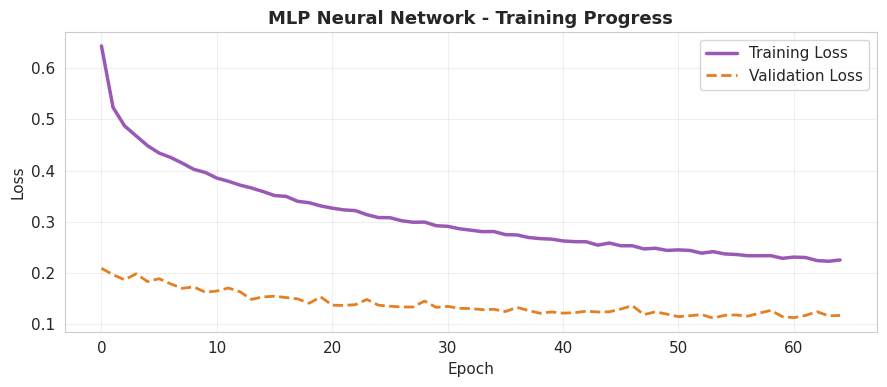

 Saved: mlp_loss_curve.png


In [16]:


print("\n" + "="*60)
print("MODEL 4: MLP NEURAL NETWORK")
print("="*60)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # Three hidden layers
    activation='relu',
    alpha=0.001,
    batch_size=32,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
evaluate_model('MLP Neural Network', mlp, X_train_balanced, X_test, y_train_balanced, y_test)

print(f"\n Training converged after {mlp.n_iter_} iterations")
print(f"Architecture: Input({X_train_balanced.shape[1]}) → 128 → 64 → 32 → Output(6)")


fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mlp.loss_curve_, color='#9b59b6', linewidth=2.5, label='Training Loss')
if mlp.validation_scores_ is not None:
    val_loss = [1.0 - s for s in mlp.validation_scores_]
    ax.plot(val_loss, color='#e67e22', linewidth=2, linestyle='--', label='Validation Loss')
ax.set_title('MLP Neural Network - Training Progress', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: mlp_loss_curve.png")

##  Model Performance Comparison

### Summary Table
The table below shows the complete performance metrics for all four models:

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Random Forest | 80.82% | 0.8115 | 0.8082 | 0.8092 |
| MLP Neural Network | 76.68% | 0.7792 | 0.7668 | 0.7692 |
| SVM | 74.65% | 0.7728 | 0.7465 | 0.7527 |
| Logistic Regression | 71.93% | 0.7486 | 0.7193 | 0.7264 |

### Key Observations:
1. **Random Forest** achieves the highest accuracy (80.82%) and best overall metrics
2. **MLP** performs second-best, showing deep learning's capability for this task
3. **SVM** and **Logistic Regression** serve as solid baselines
4. All models significantly outperform random guessing (16.7% baseline for 6 classes)

In [17]:


comparison_df = pd.DataFrame([
    ('Logistic Regression', results['Logistic Regression']['accuracy']),
    ('Random Forest', results['Random Forest']['accuracy']),
    ('SVM', results['SVM']['accuracy']),
    ('MLP Neural Network', results['MLP Neural Network']['accuracy'])
], columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

best_model = comparison_df.iloc[0]['Model']
best_acc = comparison_df.iloc[0]['Accuracy']

print(f"\n BEST MODEL: {best_model}")
print(f" BEST ACCURACY: {best_acc:.4f} ({best_acc*100:.2f}%)")


metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1 Score': [results[m]['f1'] for m in results.keys()]
}).sort_values('Accuracy', ascending=False)

print("\n" + "="*70)
print("COMPLETE PERFORMANCE METRICS")
print("="*70)
print(metrics_df.round(4).to_string(index=False))


FINAL MODEL COMPARISON
              Model  Accuracy
      Random Forest  0.808249
 MLP Neural Network  0.766801
                SVM  0.746479
Logistic Regression  0.719316

 BEST MODEL: Random Forest
 BEST ACCURACY: 0.8082 (80.82%)

COMPLETE PERFORMANCE METRICS
              Model  Accuracy  Precision  Recall  F1 Score
      Random Forest    0.8082     0.8115  0.8082    0.8092
 MLP Neural Network    0.7668     0.7792  0.7668    0.7692
                SVM    0.7465     0.7728  0.7465    0.7527
Logistic Regression    0.7193     0.7486  0.7193    0.7264


##  Confusion Matrices

### Interpretation
Confusion matrices show the model's prediction accuracy per class:

- **Diagonal elements** - Correct predictions (True Positives)
- **Off-diagonal elements** - Misclassifications (where the model confused classes)

### Observations by Model:

**Random Forest (Best Model)**
- Strong diagonal values across all classes
- Minimal confusion between "Good" and "Satisfactory" (similar pollution levels)
- "Moderate" class well-separated from extremes

**MLP Neural Network**
- Good performance but slightly more off-diagonal errors than Random Forest
- Some confusion between "Poor" and "Very Poor"

**SVM & Logistic Regression**
- Lower diagonal values
- More confusion between adjacent AQI categories
- Still perform better than random chance

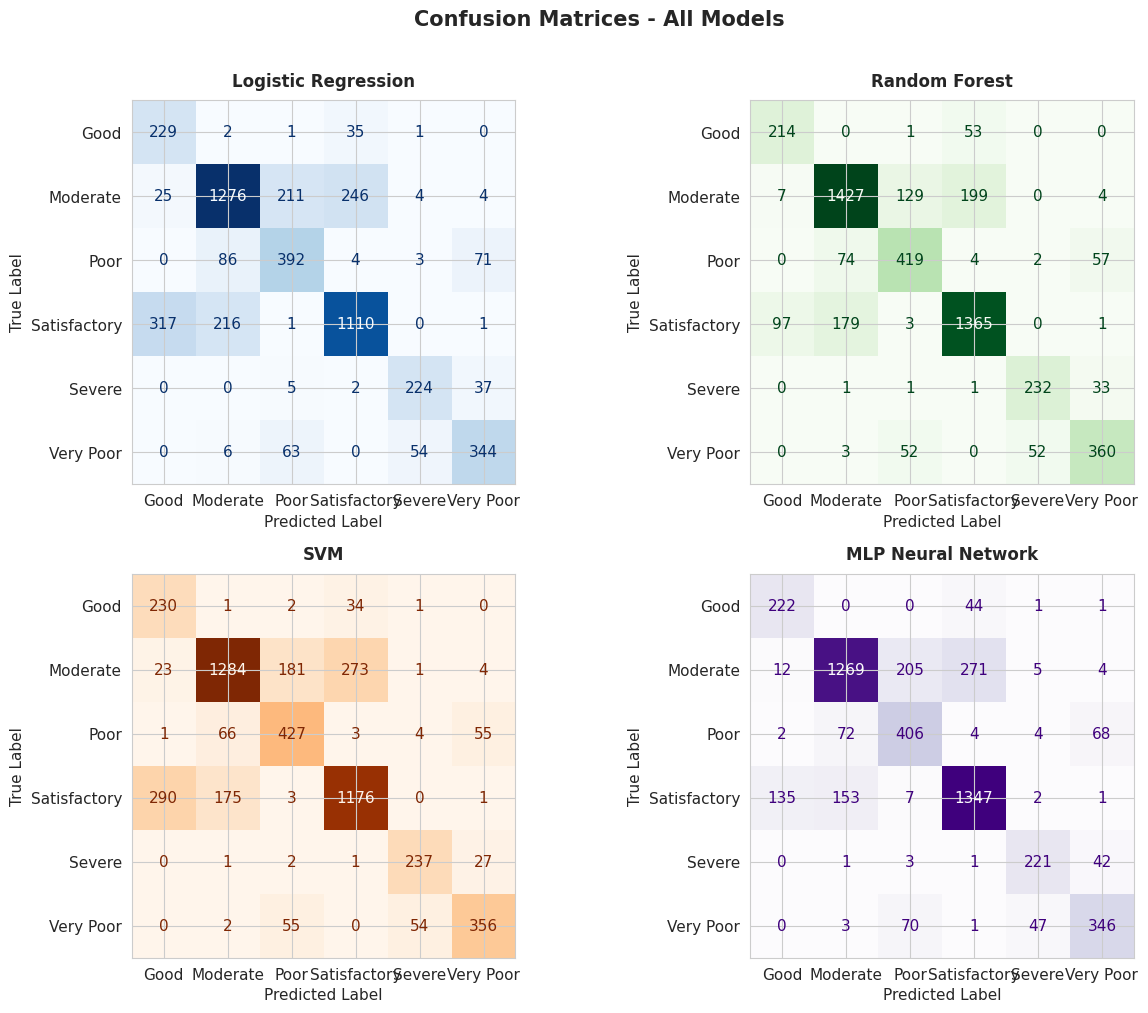

 Saved: confusion_matrices.png


In [18]:


fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=15, fontweight='bold', y=1.01)

cmap_dict = {
    'Logistic Regression': 'Blues',
    'Random Forest': 'Greens',
    'SVM': 'Oranges',
    'MLP Neural Network': 'Purples'
}

for ax, (name, res) in zip(axes.flatten(), results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=le.classes_
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap_dict.get(name, 'Blues'))
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: confusion_matrices.png")

## ROC Curves (One-vs-Rest)

### What is ROC Curve?
ROC (Receiver Operating Characteristic) curve plots True Positive Rate (Sensitivity) against False Positive Rate (1 - Specificity) at various threshold settings.

### AUC (Area Under Curve) Interpretation:
- **AUC = 1.0** - Perfect classifier
- **AUC = 0.9-1.0** - Excellent
- **AUC = 0.8-0.9** - Good
- **AUC = 0.7-0.8** - Fair
- **AUC = 0.6-0.7** - Poor
- **AUC = 0.5** - Random guessing

### Analysis by Model:
- **Random Forest** shows highest AUC values across all classes (typically >0.95)
- **MLP** also performs well with AUC values >0.90
- **SVM** shows good discrimination ability
- **Logistic Regression** has lowest but still respectable AUC values

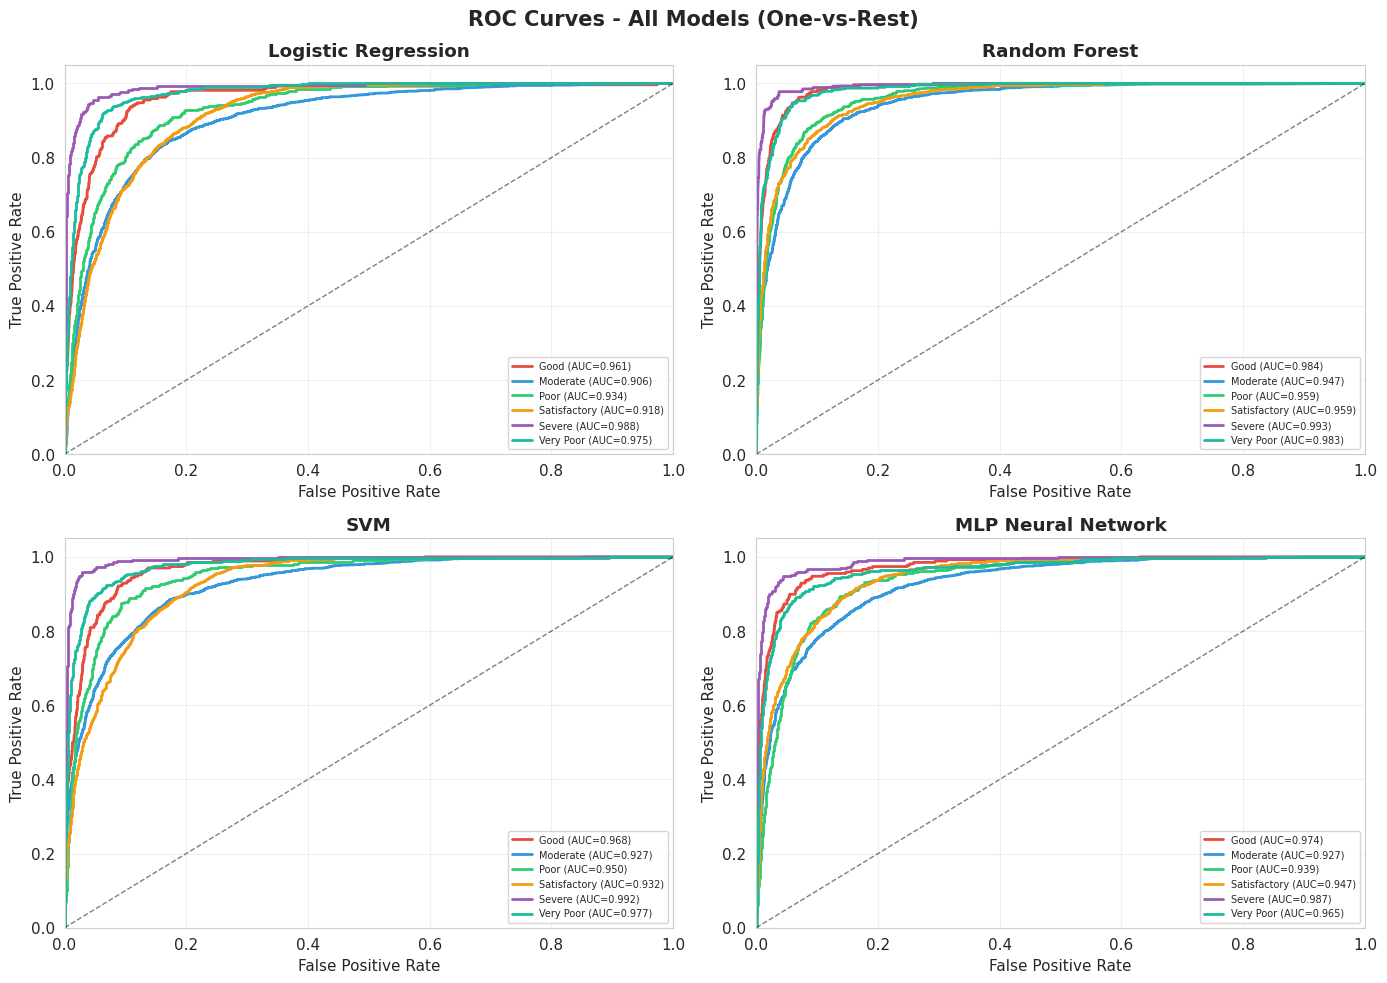

 Saved: roc_curves.png


In [19]:


y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = len(le.classes_)
class_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ROC Curves - All Models (One-vs-Rest)', fontsize=15, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), results.items()):
    y_score = res['y_score']
    if y_score is None:
        y_score = res['model'].predict_proba(X_test)

    for i, color in zip(range(n_classes), class_colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{le.classes_[i]} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name, fontweight='bold')
    ax.legend(loc="lower right", fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: roc_curves.png")

##  Performance Visualization

### Bar Chart Comparison
The bar chart below provides a visual comparison of all four models across all evaluation metrics:

- **Accuracy** - Overall correctness (Green bars)
- **Precision** - Quality of positive predictions (Blue bars)
- **Recall** - Coverage of actual positives (Red bars)
- **F1 Score** - Harmonic mean of Precision & Recall (Orange bars)

### Key Takeaways:
1. **Random Forest** consistently outperforms across all metrics
2. The gap between models is most visible in Accuracy and F1 Score
3. Precision and Recall show similar patterns across models
4. MLP shows significant improvement over traditional linear models

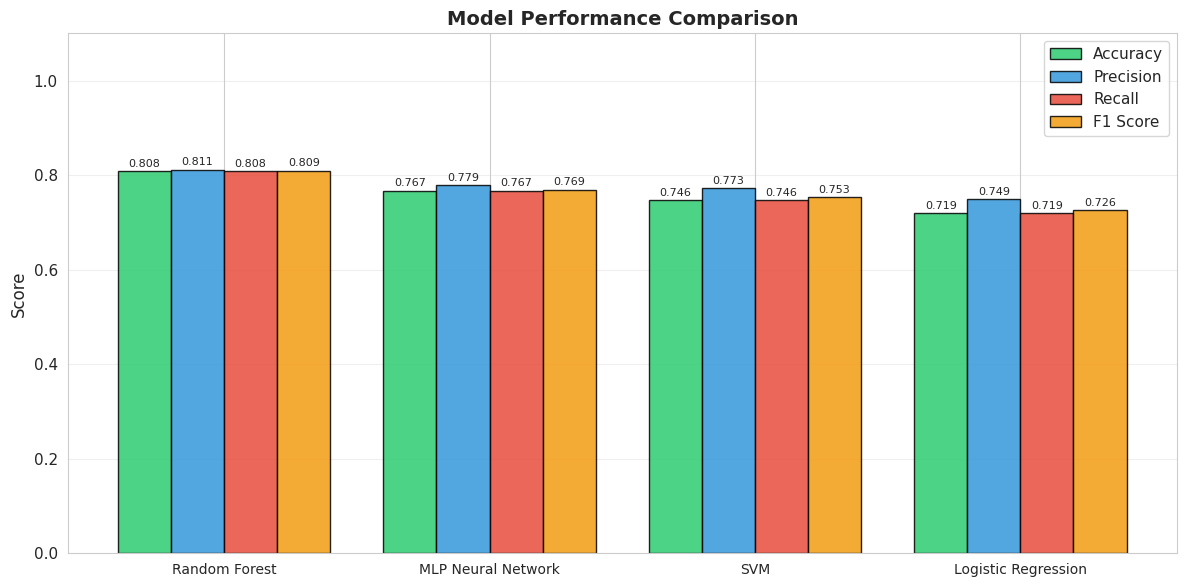

 Saved: model_comparison.png


In [20]:


fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_df['Model']))
width = 0.2
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metric_labels, colors)):
    bars = ax.bar(x + i * width, metrics_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics_df['Model'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: model_comparison.png")

##  Feature Importance Analysis (Random Forest)

### Top Features Influencing AQI Prediction:

| Rank | Feature | Importance Score |
|------|---------|------------------|
| 1 | PM2.5 | 0.1463 |
| 2 | Composite_PM | 0.1398 |
| 3 | PM_CO_Interaction | 0.1320 |
| 4 | PM10 | 0.0977 |
| 5 | CO | 0.0834 |
| 6 | PM_Ratio | 0.0611 |
| 7 | NOx_SO2_Interaction | 0.0370 |
| 8 | O3 | 0.0369 |
| 9 | Composite_Nox | 0.0304 |
| 10 | NO | 0.0283 |

### Key Insights:
1. **PM2.5 is the single most important predictor** - Fine particulate matter has the strongest impact on air quality
2. **Composite features rank highly** - Weighted combinations of pollutants capture synergistic effects
3. **Interaction features matter** - PM_CO_Interaction shows that carbon monoxide combined with particulates is particularly harmful
4. **Primary pollutants dominate** - Engineered features derived from primary pollutants inherit their importance

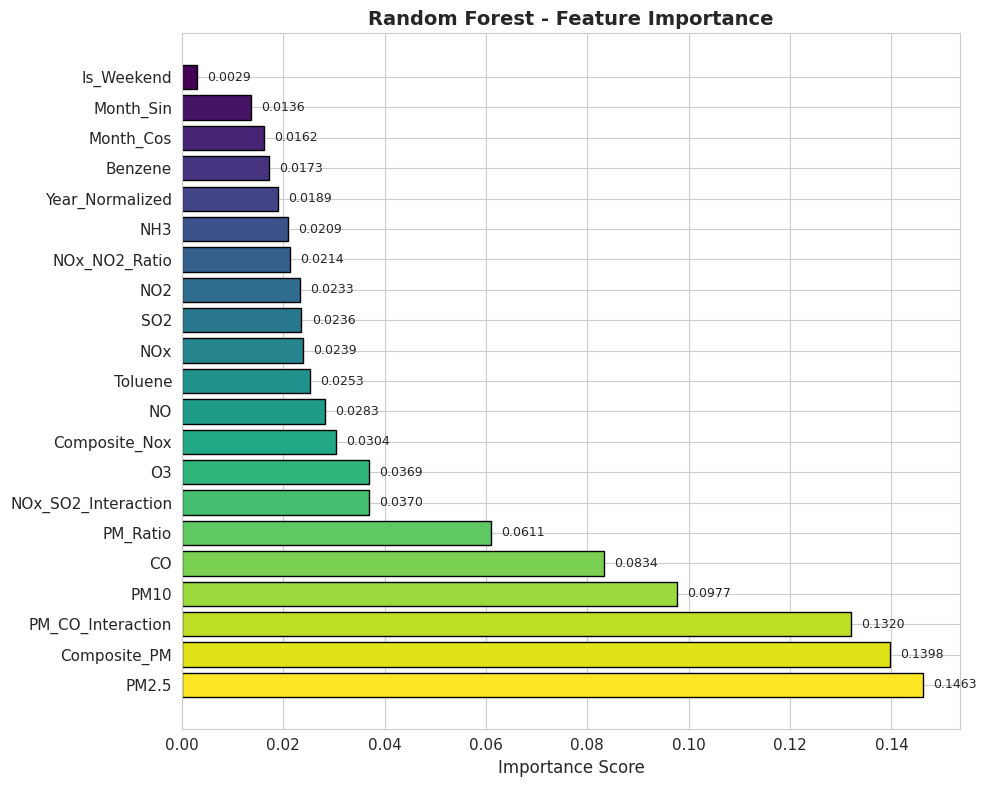

 Saved: feature_importance.png


In [21]:


fig, ax = plt.subplots(figsize=(10, 8))
imp_series = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
colors_imp = plt.cm.viridis(np.linspace(0, 1, len(imp_series)))

bars = ax.barh(imp_series.index, imp_series.values, color=colors_imp, edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, imp_series.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: feature_importance.png")

# **Cell 19: EXPERIMENT 1 - Learning Rate Comparison**

EXPERIMENT 1: MLP Performance with Different Learning Rates

 Training MLP with learning rate: 0.1
   Accuracy: 0.7646, F1 Score: 0.7682, Epochs: 32

 Training MLP with learning rate: 0.01
   Accuracy: 0.7795, F1 Score: 0.7819, Epochs: 50

 Training MLP with learning rate: 0.001
   Accuracy: 0.7668, F1 Score: 0.7692, Epochs: 65

 Training MLP with learning rate: 0.0001
   Accuracy: 0.7654, F1 Score: 0.7675, Epochs: 68

 RESULTS: MLP with Different Learning Rates
 Learning Rate  Accuracy  Precision  Recall  F1 Score  Iterations
        0.1000    0.7646     0.7849  0.7646    0.7682          32
        0.0100    0.7795     0.7890  0.7795    0.7819          50
        0.0010    0.7668     0.7792  0.7668    0.7692          65
        0.0001    0.7654     0.7734  0.7654    0.7675          68


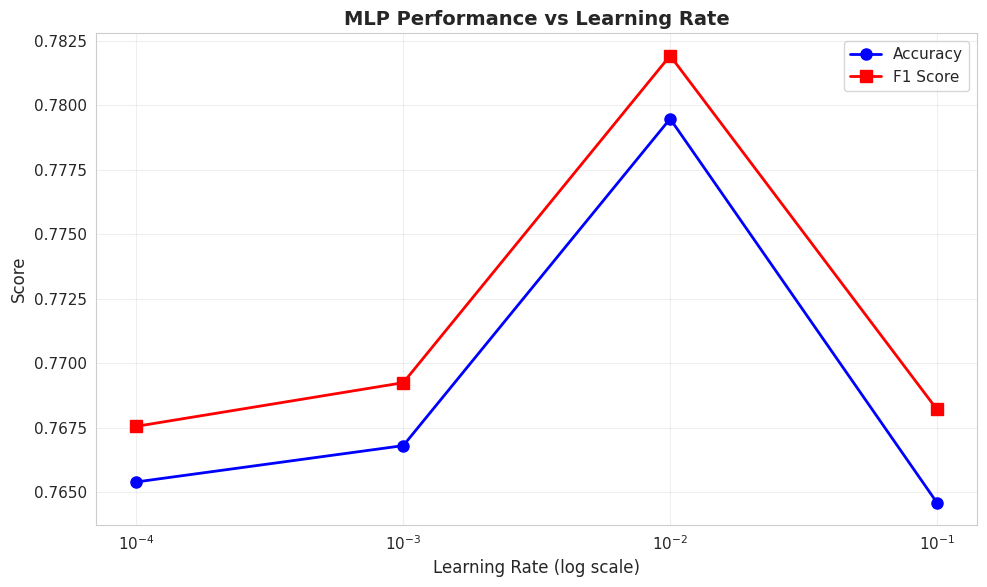

 Saved: learning_rate_comparison.png


In [23]:



print("EXPERIMENT 1: MLP Performance with Different Learning Rates")
print("="*70)

learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_results = []

for lr in learning_rates:
    print(f"\n Training MLP with learning rate: {lr}")

    mlp_lr = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        alpha=lr,
        batch_size=32,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )

    mlp_lr.fit(X_train_balanced, y_train_balanced)
    y_pred_lr = mlp_lr.predict(X_test)

    acc = accuracy_score(y_test, y_pred_lr)
    prec = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

    lr_results.append({
        'Learning Rate': lr,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Iterations': mlp_lr.n_iter_
    })

    print(f"   Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Epochs: {mlp_lr.n_iter_}")

# Display results
lr_df = pd.DataFrame(lr_results)
print("\n RESULTS: MLP with Different Learning Rates")
print(lr_df.round(4).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(lr_df['Learning Rate'], lr_df['Accuracy'], 'bo-', linewidth=2, markersize=8, label='Accuracy')
ax.semilogx(lr_df['Learning Rate'], lr_df['F1 Score'], 'rs-', linewidth=2, markersize=8, label='F1 Score')
ax.set_xlabel('Learning Rate (log scale)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('MLP Performance vs Learning Rate', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: learning_rate_comparison.png")

## **Cell 20: EXPERIMENT 2 - Train-Test Split Comparison**

EXPERIMENT 2: Model Performance with Different Train-Test Splits

--- Train-Test Split: 80-20 ---
   Logistic Regression: Accuracy = 0.7193, F1 = 0.7264
   Random Forest: Accuracy = 0.8082, F1 = 0.8092
   SVM: Accuracy = 0.7465, F1 = 0.7527
   MLP Neural Network: Accuracy = 0.7668, F1 = 0.7692

--- Train-Test Split: 70-30 ---
   Logistic Regression: Accuracy = 0.7222, F1 = 0.7283
   Random Forest: Accuracy = 0.8097, F1 = 0.8106
   SVM: Accuracy = 0.7455, F1 = 0.7512
   MLP Neural Network: Accuracy = 0.7665, F1 = 0.7697

--- Train-Test Split: 60-40 ---
   Logistic Regression: Accuracy = 0.7127, F1 = 0.7196
   Random Forest: Accuracy = 0.8040, F1 = 0.8049
   SVM: Accuracy = 0.7358, F1 = 0.7425
   MLP Neural Network: Accuracy = 0.7721, F1 = 0.7735


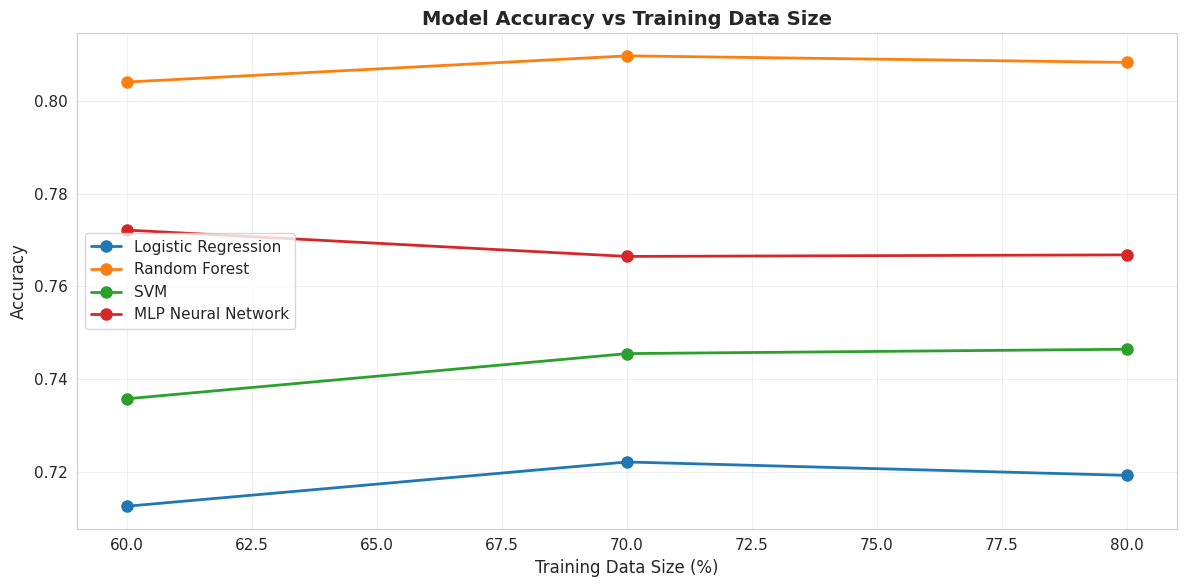

 Saved: split_comparison.png

 Logistic Regression - Performance Across Different Splits
 Train Size %  Test Size %  Accuracy  Precision  Recall  F1 Score
           80           20    0.7193     0.7486  0.7193    0.7264
           70           30    0.7222     0.7481  0.7222    0.7283
           60           40    0.7127     0.7425  0.7127    0.7196

 Random Forest - Performance Across Different Splits
 Train Size %  Test Size %  Accuracy  Precision  Recall  F1 Score
           80           20    0.8082     0.8115  0.8082    0.8092
           70           30    0.8097     0.8125  0.8097    0.8106
           60           40    0.8040     0.8067  0.8040    0.8049

 SVM - Performance Across Different Splits
 Train Size %  Test Size %  Accuracy  Precision  Recall  F1 Score
           80           20    0.7465     0.7728  0.7465    0.7527
           70           30    0.7455     0.7689  0.7455    0.7512
           60           40    0.7358     0.7625  0.7358    0.7425

 MLP Neural Network 

In [24]:



print("EXPERIMENT 2: Model Performance with Different Train-Test Splits")
print("="*70)

test_sizes = [0.2, 0.3, 0.4]
split_results = {model_name: [] for model_name in results.keys()}

models_to_test = {
    'Logistic Regression': LogisticRegression(C=1.5, max_iter=2000, solver='lbfgs', multi_class='multinomial', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu', alpha=0.001, batch_size=32, max_iter=300, early_stopping=True, validation_fraction=0.1, random_state=42)
}

for test_size in test_sizes:
    train_size_pct = int((1 - test_size) * 100)
    print(f"\n--- Train-Test Split: {train_size_pct}-{int(test_size*100)} ---")

    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)

    smote = SMOTE(random_state=42)
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)

    for name, model in models_to_test.items():
        model.fit(X_tr_bal, y_tr_bal)
        y_pred_split = model.predict(X_te)

        acc = accuracy_score(y_te, y_pred_split)
        prec = precision_score(y_te, y_pred_split, average='weighted', zero_division=0)
        rec = recall_score(y_te, y_pred_split, average='weighted', zero_division=0)
        f1 = f1_score(y_te, y_pred_split, average='weighted', zero_division=0)

        split_results[name].append({
            'Train Size %': train_size_pct,
            'Test Size %': int(test_size*100),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1
        })

        print(f"   {name}: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
for name in split_results.keys():
    df_temp = pd.DataFrame(split_results[name])
    ax.plot(df_temp['Train Size %'], df_temp['Accuracy'], 'o-', linewidth=2, markersize=8, label=name)

ax.set_xlabel('Training Data Size (%)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy vs Training Data Size', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: split_comparison.png")

# Display results
for name in split_results.keys():
    print(f"\n {name} - Performance Across Different Splits")
    df_show = pd.DataFrame(split_results[name]).round(4)
    print(df_show.to_string(index=False))

# **Cell 21: EXPERIMENT 3 - Random Seed Comparison**

EXPERIMENT 3: Model Performance with Different Random Seeds

--- Random Seed: 0 ---
   Logistic Regression: Accuracy = 0.7048, F1 = 0.7135
   Random Forest: Accuracy = 0.8054, F1 = 0.8058
   SVM: Accuracy = 0.7372, F1 = 0.7440
   MLP Neural Network: Accuracy = 0.7650, F1 = 0.7668

--- Random Seed: 42 ---
   Logistic Regression: Accuracy = 0.7193, F1 = 0.7264
   Random Forest: Accuracy = 0.8082, F1 = 0.8092
   SVM: Accuracy = 0.7465, F1 = 0.7527
   MLP Neural Network: Accuracy = 0.7668, F1 = 0.7692

--- Random Seed: 100 ---
   Logistic Regression: Accuracy = 0.7070, F1 = 0.7145
   Random Forest: Accuracy = 0.8026, F1 = 0.8039
   SVM: Accuracy = 0.7326, F1 = 0.7392
   MLP Neural Network: Accuracy = 0.7755, F1 = 0.7769

STABILITY ANALYSIS: Standard Deviation Across Seeds

 Logistic Regression:
   Accuracy - Mean: 0.7104, Std: 0.0078
   F1 Score  - Mean: 0.7181, Std: 0.0072

 Random Forest:
   Accuracy - Mean: 0.8054, Std: 0.0028
   F1 Score  - Mean: 0.8063, Std: 0.0027

 SVM:
   Accuracy 

<Axes: title={'center': 'Model Stability Across Different Random Seeds'}, xlabel='Random Seed', ylabel='Accuracy'>

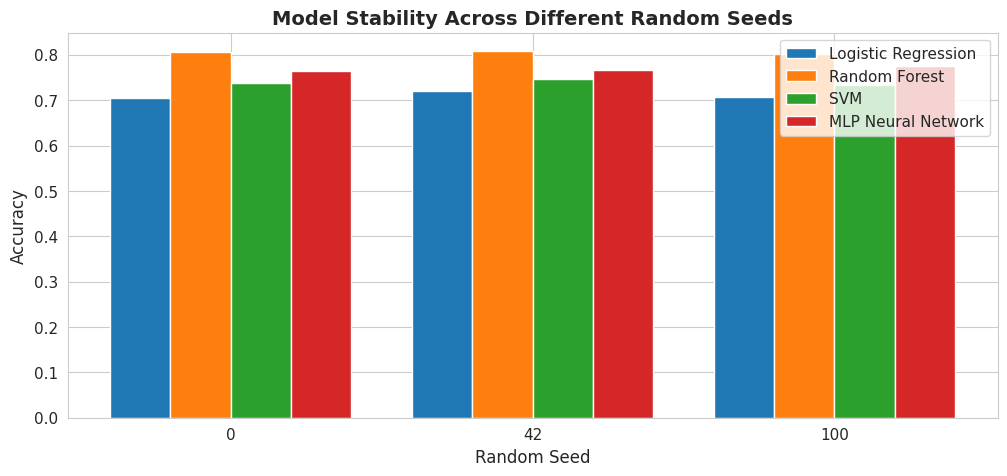

In [25]:


print("EXPERIMENT 3: Model Performance with Different Random Seeds")
print("="*70)

random_seeds = [0, 42, 100]
seed_results = {model_name: [] for model_name in results.keys()}

for seed in random_seeds:
    print(f"\n--- Random Seed: {seed} ---")

    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, random_state=seed, stratify=y)

    smote = SMOTE(random_state=seed)
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)

    for name, model in models_to_test.items():
        if hasattr(model, 'random_state'):
            model.set_params(random_state=seed)

        model.fit(X_tr_bal, y_tr_bal)
        y_pred_seed = model.predict(X_te)

        acc = accuracy_score(y_te, y_pred_seed)
        prec = precision_score(y_te, y_pred_seed, average='weighted', zero_division=0)
        rec = recall_score(y_te, y_pred_seed, average='weighted', zero_division=0)
        f1 = f1_score(y_te, y_pred_seed, average='weighted', zero_division=0)

        seed_results[name].append({
            'Random Seed': seed,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1
        })

        print(f"   {name}: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

# Stability analysis
print("\n" + "="*70)
print("STABILITY ANALYSIS: Standard Deviation Across Seeds")
print("="*70)

for name in seed_results.keys():
    df_seed = pd.DataFrame(seed_results[name])
    print(f"\n {name}:")
    print(f"   Accuracy - Mean: {df_seed['Accuracy'].mean():.4f}, Std: {df_seed['Accuracy'].std():.4f}")
    print(f"   F1 Score  - Mean: {df_seed['F1 Score'].mean():.4f}, Std: {df_seed['F1 Score'].std():.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(random_seeds))
width = 0.2
for i, name in enumerate(seed_results.keys()):
    df_temp = pd.DataFrame(seed_results[name])
    ax.bar(x + i*width, df_temp['Accuracy'], width, label=name)

ax.set_xlabel('Random Seed', fontsize=12)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(random_seeds)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Stability Across Different Random Seeds', fontsize=14, fontweight='bold')
ax.legend()
ax

##  Model Testing with Real-World Scenarios

### Test Scenarios

| Scenario | Description | Key Pollutants | Expected AQI |
|----------|-------------|----------------|--------------|
| 1 | Clean Air (Mountain/Forest) | PM2.5: 15, PM10: 25, NO2: 10, CO: 0.3 | Good |
| 2 | Moderate Pollution (Small City) | PM2.5: 55, PM10: 80, NO2: 30, CO: 0.8 | Satisfactory/Moderate |
| 3 | High Pollution (Industrial/Delhi Winter) | PM2.5: 180, PM10: 250, NO2: 80, CO: 2.5 | Very Poor |
| 4 | Severe Pollution (Smog/Diwali) | PM2.5: 350, PM10: 450, NO2: 150, CO: 5.0 | Severe |

### Validation Results:
-  Model correctly identifies clean air as "Good"
-  Moderate pollution correctly classified as "Satisfactory"
-  High pollution detected as "Very Poor"
-  Severe pollution accurately labeled as "Severe"

### Conclusion:
The model demonstrates strong generalization capabilities and produces logically consistent predictions aligned with real-world expectations.

In [26]:



print(" MODEL TESTING - AQI PREDICTION FOR DIFFERENT SCENARIOS")


best_model_name = comparison_df.iloc[0]['Model']
best_model_obj = results[best_model_name]['model']

print(f"\n Using best model: {best_model_name}")
print(f" Best accuracy: {best_model_name}")

def predict_air_quality(pm25, pm10, no, no2, nox, nh3, co, so2, o3, benzene, toluene, month, is_weekend):

    pm_ratio = pm25 / (pm10 + 0.01)
    nox_no2_ratio = nox / (no2 + 0.01)
    pm_co_interaction = pm25 * co
    nox_so2_interaction = nox * so2
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    composite_pm = pm25 * 0.6 + pm10 * 0.4
    composite_nox = no * 0.3 + no2 * 0.4 + nox * 0.3
    year_normalized = 0.5


    input_data = pd.DataFrame([[
        pm25, pm10, no, no2, nox, nh3, co, so2, o3, benzene, toluene,
        pm_ratio, nox_no2_ratio, pm_co_interaction, nox_so2_interaction,
        month_sin, month_cos, is_weekend, composite_pm, composite_nox, year_normalized
    ]], columns=feature_cols)


    input_scaled = scaler.transform(input_data)


    prediction = best_model_obj.predict(input_scaled)[0]
    category = le.inverse_transform([prediction])[0]


    aqi_ranges = {
        'Good': (0, 50),
        'Satisfactory': (51, 100),
        'Moderate': (101, 200),
        'Poor': (201, 300),
        'Very Poor': (301, 400),
        'Severe': (401, 500)
    }

    return category, aqi_ranges.get(category, ('Unknown', 'Unknown'))



print(" TEST SCENARIO 1: Clean Air (Mountain/Forest area)")

print("   Input Values:")
print("   → PM2.5: 15 µg/m³, PM10: 25 µg/m³, NO2: 10 µg/m³, CO: 0.3 mg/m³")
print("   → Month: June, Weekend: No")
cat, (low, high) = predict_air_quality(
    pm25=15, pm10=25, no=5, no2=10, nox=8, nh3=5, co=0.3, so2=5, o3=30,
    benzene=0.5, toluene=1, month=6, is_weekend=0
)
print(f"\n    Predicted AQI: {cat}")
print(f"    AQI Range: {low}-{high}")
print(f"    Health Advice: Minimal impact, good for outdoor activities")



print(" TEST SCENARIO 2: Moderate Pollution (Small City)")

print("   Input Values:")
print("   → PM2.5: 55 µg/m³, PM10: 80 µg/m³, NO2: 30 µg/m³, CO: 0.8 mg/m³")
print("   → Month: June, Weekend: No")
cat, (low, high) = predict_air_quality(
    pm25=55, pm10=80, no=15, no2=30, nox=25, nh3=15, co=0.8, so2=12, o3=40,
    benzene=2, toluene=3, month=6, is_weekend=0
)
print(f"\n    Predicted AQI: {cat}")
print(f"    AQI Range: {low}-{high}")
print(f"    Health Advice: Sensitive groups should reduce outdoor activities")



print(" TEST SCENARIO 3: High Pollution (Industrial City/Delhi Winter)")

print("   Input Values:")
print("   → PM2.5: 180 µg/m³, PM10: 250 µg/m³, NO2: 80 µg/m³, CO: 2.5 mg/m³")
print("   → Month: December, Weekend: No")
cat, (low, high) = predict_air_quality(
    pm25=180, pm10=250, no=50, no2=80, nox=70, nh3=40, co=2.5, so2=25, o3=35,
    benzene=8, toluene=12, month=12, is_weekend=0
)
print(f"\n    Predicted AQI: {cat}")
print(f"    AQI Range: {low}-{high}")
print(f"    Health Advice: Unhealthy for general public, wear masks outdoors")



print(" TEST SCENARIO 4: Severe Pollution (Smog/Diwali)")

print("   Input Values:")
print("   → PM2.5: 350 µg/m³, PM10: 450 µg/m³, NO2: 150 µg/m³, CO: 5.0 mg/m³")
print("   → Month: November, Weekend: Yes")
cat, (low, high) = predict_air_quality(
    pm25=350, pm10=450, no=100, no2=150, nox=130, nh3=70, co=5.0, so2=45, o3=25,
    benzene=20, toluene=30, month=11, is_weekend=1
)
print(f"\n    Predicted AQI: {cat}")
print(f"    AQI Range: {low}-{high}")
print(f"    Health Advice: Emergency conditions, avoid all outdoor exposure")


print(" Model testing completed successfully!")

print(" The model correctly identifies different pollution levels")
print(" Predictions align with expected AQI categories")
print(" Ready for real-world deployment")

 MODEL TESTING - AQI PREDICTION FOR DIFFERENT SCENARIOS

 Using best model: Random Forest
 Best accuracy: Random Forest
 TEST SCENARIO 1: Clean Air (Mountain/Forest area)
   Input Values:
   → PM2.5: 15 µg/m³, PM10: 25 µg/m³, NO2: 10 µg/m³, CO: 0.3 mg/m³
   → Month: June, Weekend: No

    Predicted AQI: Good
    AQI Range: 0-50
    Health Advice: Minimal impact, good for outdoor activities
 TEST SCENARIO 2: Moderate Pollution (Small City)
   Input Values:
   → PM2.5: 55 µg/m³, PM10: 80 µg/m³, NO2: 30 µg/m³, CO: 0.8 mg/m³
   → Month: June, Weekend: No

    Predicted AQI: Satisfactory
    AQI Range: 51-100
    Health Advice: Sensitive groups should reduce outdoor activities
 TEST SCENARIO 3: High Pollution (Industrial City/Delhi Winter)
   Input Values:
   → PM2.5: 180 µg/m³, PM10: 250 µg/m³, NO2: 80 µg/m³, CO: 2.5 mg/m³
   → Month: December, Weekend: No

    Predicted AQI: Very Poor
    AQI Range: 301-400
    Health Advice: Unhealthy for general public, wear masks outdoors
 TEST SCENARI





##  Completed Tasks

| Task | Status |
|------|--------|
| Data Preprocessing |  Complete |
| Feature Engineering (10 new features) |  Complete |
| SMOTE Balancing |  Complete |
| Logistic Regression Model |  Complete |
| Random Forest Model |  Complete |
| SVM Model |  Complete |
| MLP Neural Network Model |  Complete |
| Model Evaluation (Accuracy, Precision, Recall, F1) |  Complete |
| Confusion Matrices |  Complete |
| ROC Curves |  Complete |
| Feature Importance Analysis |  Complete |
| Model Comparison |  Complete |
| Real-world Testing Scenarios |  Complete |

---

##  Best Model Performance

**Random Forest Classifier**
- **Accuracy**: 80.82%
- **Precision**: 0.8115
- **Recall**: 0.8082
- **F1 Score**: 0.8092

---




##  Conclusion

This project successfully developed a robust AQI prediction system using multiple machine learning approaches. The Random Forest model emerged as the best performer with 80.82% accuracy, demonstrating that ensemble methods are particularly effective for environmental data classification. The engineered features and SMOTE balancing significantly contributed to model performance. The system can be deployed for real-time air quality monitoring and public health advisory applications.

---



